# Chapter 10.2 — Evaluating a Classifier

*Course 888102 · International College of Digital Innovation, Chiang Mai University*

Part 10.1 grew a decision tree from fourteen golf days and read it as five rules; it scored 100% on the days it was grown from. This part asks how good the tree really is. It applies the Chapter 9 toolkit — predicted against actual, the four boxes of the confusion matrix, accuracy, precision, recall and F₁ — to that tree, and then on 569 tumors split into rows to learn from and rows held back. The same evaluation is then applied to a real dataset — 569 breast-cancer tumors — with scikit-learn, and the a short in-class exercise applies the same lines to another dataset.

**In this chapter:** Predicted against actual · The four boxes · Accuracy, precision, recall, F₁ · Training against test data · The breast-cancer tumors · scikit-learn · In-class exercise



> **Learning objectives.** By the end of this part you should be able to:
>
> - **Compare predicted with actual** — lay a model's answers beside what really happened, and place every case in one of four boxes.
> - **Read the four metrics** — accuracy, precision, recall and F₁ as ratios of the boxes, and which mistake each one sees.
> - **Test on unseen data** — say why the score on the training rows is only how well the model fits, and measure how well it predicts.
> - **Test on unseen rows** — hold rows back before building the model, and read the four boxes on those.



**Contents**

- **10.2.1 · The tree from Part 10.1** — the model under test, rebuilt in one cell
- **10.2.2 · The confusion matrix** — recap from Chapter 9: the four boxes and the four metrics
- **10.2.3 · The confusion matrix of the golf tree** — the four boxes, from the library
- **10.2.4 · A real dataset — the breast-cancer tumors** — the same evaluation with scikit-learn
- **10.2.5 · Glossary** — the terms of this part
- **10.2.6 · In-class exercise** — load new data, build the model, score it



> **How to use this notebook.** Each idea is explained first, then built in code one step per cell: the text above a code cell says what the step does and why it comes next, and its **Interpretation** says what the output will show. Run the cells in order — later cells use variables made by earlier ones. The in-class exercise is Section 10.2.6.

> **Continuing from Chapter 9 and Part 10.1.** Chapter 9 taught the confusion matrix and its four metrics in full (Sections 9.3.4 and 9.3.5), on a screening example of 1,000 people. They are recapped here in one place each, with Chapter 9's own numbers, and then applied to this chapter's model. Part 10.1 grew the tree; its functions are rebuilt in one cell in Section 10.2.1.



#### Setting up

One cell of preparation: numpy for arrays of numbers, pandas for tables, matplotlib for charts. Section 10.2.5 adds scikit-learn, which scores a model in one line.



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 100
print("numpy", np.__version__, "· pandas", pd.__version__, "· ready")

numpy 2.4.6 · pandas 3.0.5 · ready


## 10.2.1 · The tree from Part 10.1

*the model under test*

> **Recap from Part 10.1.** Fourteen golf days, each with four features — outlook, temperature, humidity, wind — and the answer: whether golf was played. Nine Yes, five No. Part 10.1 grew a tree from them with scikit-learn, in one line, and it was right on all fourteen days it was grown from. That is how well it fits. This part measures how well it predicts.



#### The steps

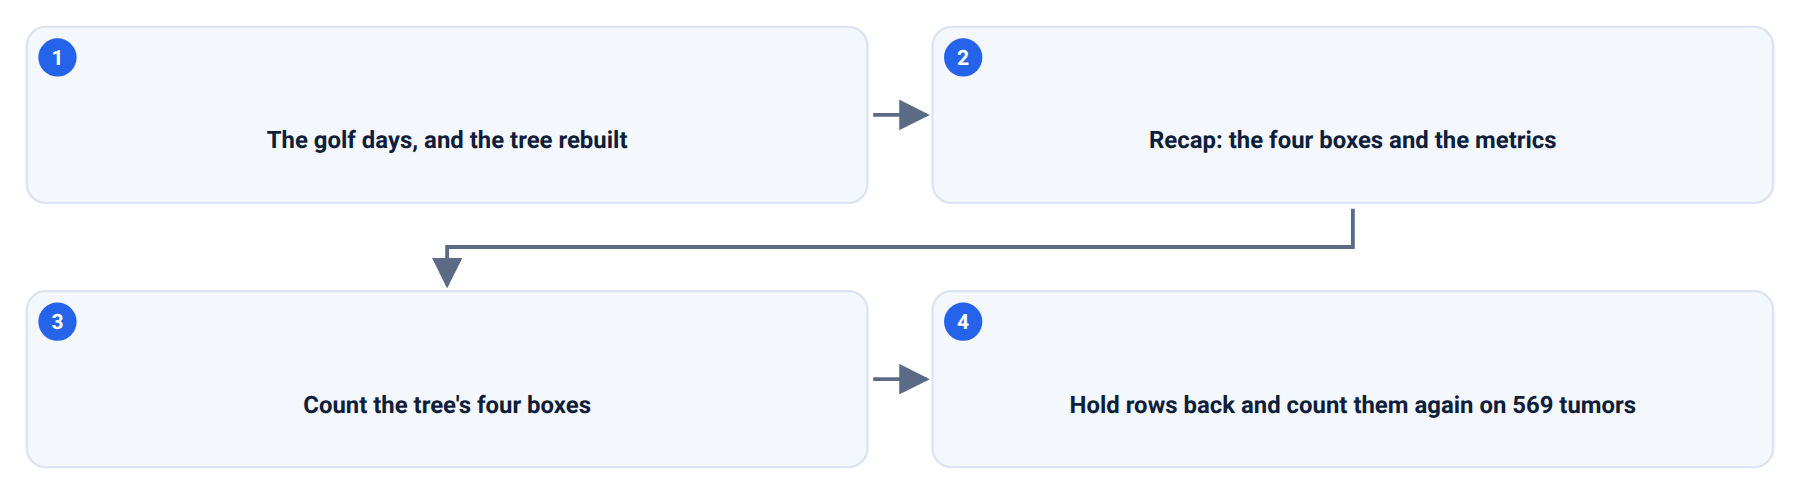

*What the cells of Sections 10.2.1 to 10.2.4 do.*



#### The golf days

The fourteen days of Part 10.1, in the same table, so this notebook stands on its own.



In [2]:
golf = pd.DataFrame({
    "outlook":  ["Rainy", "Rainy", "Overcast", "Sunny", "Sunny", "Sunny", "Overcast",
                 "Rainy", "Rainy", "Sunny", "Rainy", "Overcast", "Overcast", "Sunny"],
    "temp":     ["Hot", "Hot", "Hot", "Mild", "Cool", "Cool", "Cool",
                 "Mild", "Cool", "Mild", "Mild", "Mild", "Hot", "Mild"],
    "humidity": ["High", "High", "High", "High", "Normal", "Normal", "Normal",
                 "High", "Normal", "Normal", "Normal", "High", "Normal", "High"],
    "windy":    ["No", "Yes", "No", "No", "No", "Yes", "Yes",
                 "No", "No", "No", "Yes", "Yes", "No", "Yes"],
    "play":     ["No", "No", "Yes", "Yes", "Yes", "No", "Yes",
                 "No", "Yes", "Yes", "Yes", "Yes", "Yes", "No"],
})
golf.index = range(1, 15)
FEATURES = ["outlook", "temp", "humidity", "windy"]
golf

,outlook,temp,humidity,windy,play
1,Rainy,Hot,High,No,No
2,Rainy,Hot,High,Yes,No
3,Overcast,Hot,High,No,Yes
4,Sunny,Mild,High,No,Yes
5,Sunny,Cool,Normal,No,Yes
6,Sunny,Cool,Normal,Yes,No
7,Overcast,Cool,Normal,Yes,Yes
8,Rainy,Mild,High,No,No
9,Rainy,Cool,Normal,No,Yes
10,Sunny,Mild,Normal,No,Yes


#### The tree, rebuilt

The four columns of words are coded as numbers and the tree is grown in one line, exactly as in Part 10.1. `.score()` checks it on the days it was grown from.



> **Interpretation.** 100% — the number Part 10.1 ended on. Every question in this part is about whether that number means anything.



In [3]:
from sklearn.tree import DecisionTreeClassifier

codes = golf[FEATURES].apply(lambda col: col.astype("category").cat.codes)
model = DecisionTreeClassifier(random_state=0).fit(codes, golf["play"])
print(f"on its own 14 days: {model.score(codes, golf['play']):.0%}")

on its own 14 days: 100%


## 10.2.2 · The confusion matrix

*recap from Chapter 9*

Evaluating a classifier starts with one comparison per case: what the model predicted beside what actually happened. Every case then lands in exactly one of four boxes, and the four counts are the **confusion matrix**. In a binary problem one class is the positive class — here Yes, the days golf was played — and the boxes are named from its point of view.

|  | actually Yes | actually No |
|---|---|---|
| **predicted Yes** | **TP** — true positive, a correct catch | **FP** — false positive, a Type I error |
| **predicted No** | **FN** — false negative, a Type II error | **TN** — true negative, a correct pass |

> **Recap from Chapter 9.** Section 9.3.5 worked this on 1,000 screened people, 60 of them ill, 50 flagged, 40 of those correctly: TP 40, FP 10, FN 20, TN 930. Accuracy $970/1000 = 97.0\%$ — and 94% for a model that flags nobody. Precision $40/50 = 80.0\%$: of those flagged, the share really ill. Recall $40/60 = 66.7\%$: of the ill, the share caught. $F_1 = 72.7\%$. Accuracy is nearly blind to a rare class; precision and recall see the two mistakes separately.

$$\text{Accuracy} = \frac{TP + TN}{n} \qquad \text{Precision} = \frac{TP}{TP + FP} \qquad \text{Recall} = \frac{TP}{TP + FN} \qquad F_1 = \frac{2\,PR}{P + R}$$

*Every metric, as a ratio of the four boxes.* $n$ is every case in the table. Precision divides by the row the model chose, recall by the column the truth chose; $F_1$ balances the two — it is high only when both are.



#### The four boxes of the Chapter 9 example

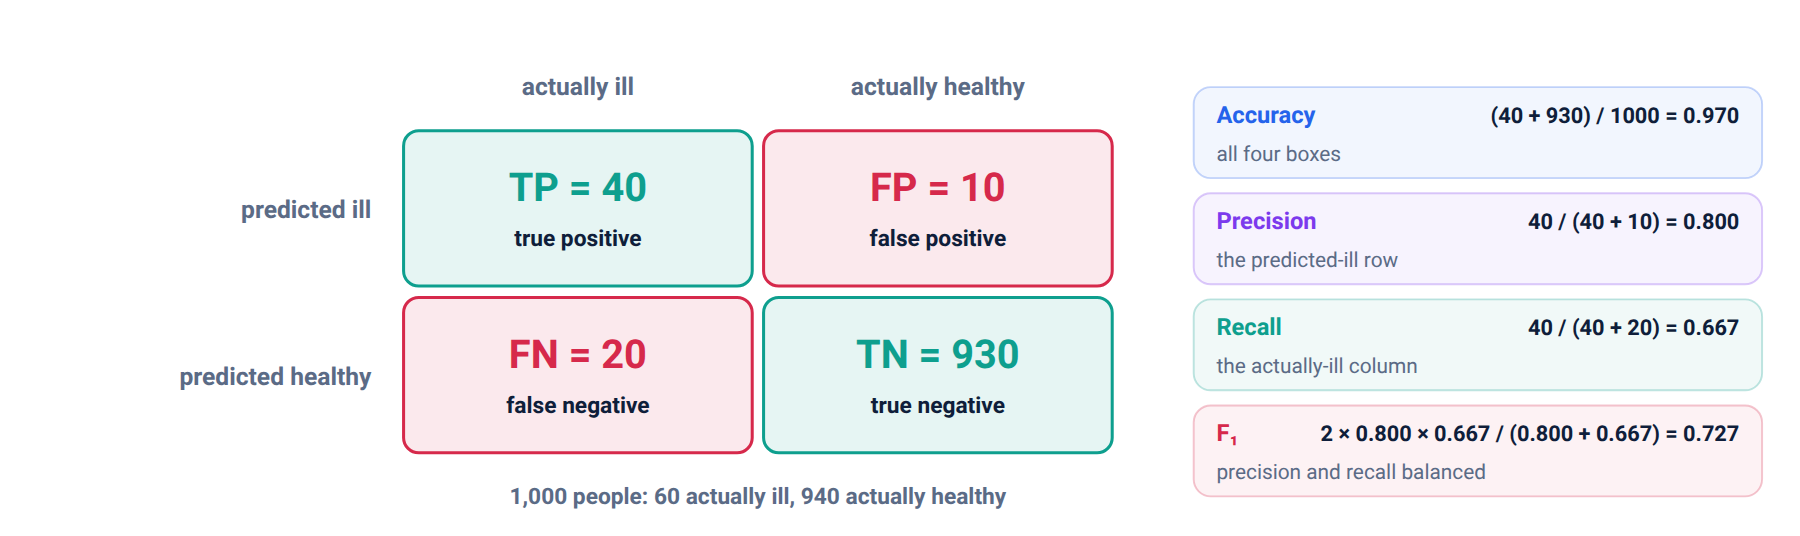

*The Chapter 9 screening example. The large TN box makes accuracy high; precision and recall read the two mistakes separately.*



## 10.2.3 · The confusion matrix of the golf tree

*the four boxes, from the library*

The tree has a prediction for every day, and every day has an answer. Putting the two side by side and counting the pairs gives the four boxes for this model, with Yes — the days golf was played — as the positive class.



#### Predicted beside actual

`.predict()` gives the tree's answer for all fourteen days at once. The predictions and the true answers go into one table, one row per day. The cell also imports the two metric functions the rest of this section uses, `confusion_matrix` and `classification_report`.



> **Interpretation.** Fourteen rows, each one a comparison. Read down the two columns and every pair agrees.



In [4]:
from sklearn.metrics import confusion_matrix, classification_report

predicted = model.predict(codes)
comparison = pd.DataFrame({"actual": golf["play"], "predicted": predicted}, index=golf.index)
comparison

,actual,predicted
1,No,No
2,No,No
3,Yes,Yes
4,Yes,Yes
5,Yes,Yes
6,No,No
7,Yes,Yes
8,No,No
9,Yes,Yes
10,Yes,Yes


#### The four boxes

`confusion_matrix` counts the pairs into the four boxes. One thing to watch: scikit-learn puts the **actual** classes down the rows and the predicted across the columns, the transpose of the table in Section 10.2.2. `labels=` fixes the order, so the top-left cell is actual No predicted No.



> **Interpretation.** TN 5, FP 0, FN 0, TP 9 — every count is on the diagonal and both mistake boxes are empty. The four counts add to 14, as they always must.



In [5]:
confusion_matrix(golf["play"], predicted, labels=["No", "Yes"])

array([[5, 0],
       [0, 9]])

#### The tree's four boxes

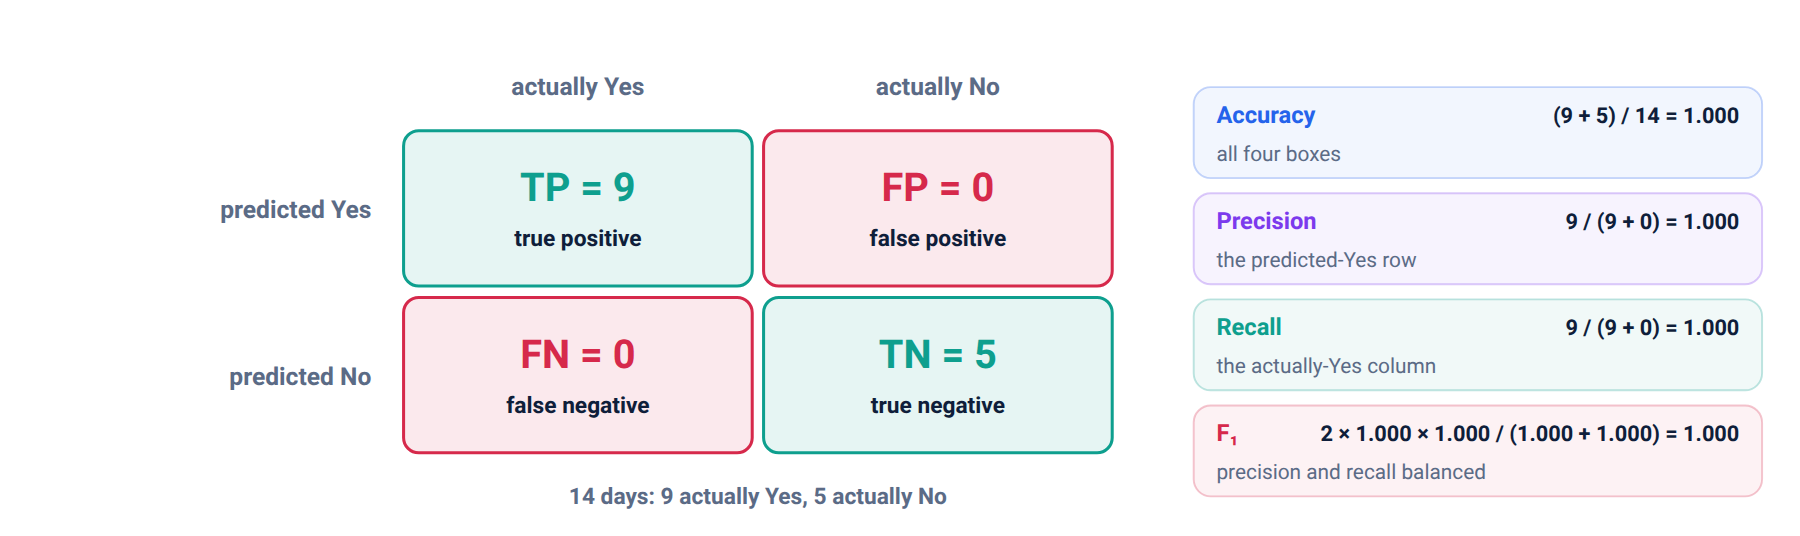

*The fourteen comparisons counted into the four boxes, with Yes as the positive class.*



#### Precision, recall and F₁ by name

`classification_report` prints the three metrics for each class, with **support** — how many days of that class there were. The row for Yes reads them from the positive class's point of view, the way the formulas of Section 10.2.2 define them.



> **Interpretation.** Every metric is 1.000, because every box off the diagonal is empty: precision 9/9, recall 9/9, and F₁ balancing two perfect numbers.



In [6]:
print(classification_report(golf["play"], predicted, digits=3))

              precision    recall  f1-score   support

          No      1.000     1.000     1.000         5
         Yes      1.000     1.000     1.000         9

    accuracy                          1.000        14
   macro avg      1.000     1.000     1.000        14
weighted avg      1.000     1.000     1.000        14



#### A perfect matrix is a warning, not a result

> **Watch out.** The tree was asked about the fourteen days it was grown from, and it kept asking questions until every group agreed — so it cannot be wrong on them. A confusion matrix of a model scored on its own data always looks like this, and it says nothing about tomorrow's weather. To mean anything, the four boxes have to be counted on data the model has not seen: rows held back before it was built. Section 10.2.4 does exactly that with 569 tumors, where 171 are kept aside and the matrix has something to show.



## 10.2.4 · A real dataset — the breast-cancer tumors

*the same evaluation with scikit-learn*

The dataset is the Wisconsin breast-cancer data, bundled with scikit-learn: 569 tumors, each described by 30 measurements taken from a digitized image of a biopsy — the size, texture and shape of the cell nuclei — and each labeled by what the biopsy found: **malignant** (cancer) or **benign** (not cancer). Two classes, so this is a binary problem, and the positive class — the one being looked for — is malignant.

> **The question.** From the 30 measurements of a tumor, how well can a decision tree tell malignant from benign — and which mistake does it make more often: calling a benign tumor malignant, or a malignant one benign?

> **The split.** With 569 rows the train/test split is made once, as in Chapter 9: 70% of the tumors train the tree and 30% are held back to test it. `train_test_split` does the splitting; `stratify=` keeps the share of malignant tumors the same in both parts, and the seed 888102 makes every student's split identical. The tree is grown three questions deep, so that it does not simply memorize the training rows.



#### The steps

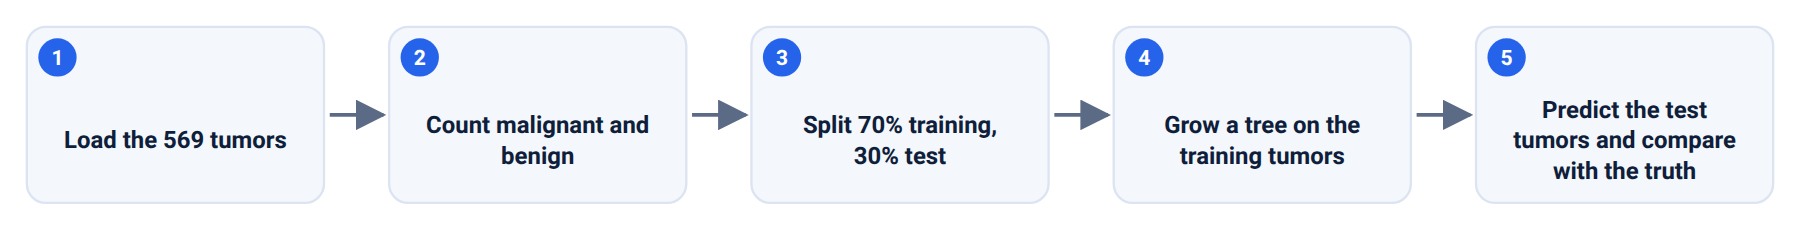

*The tumor walk. Section 10.2.6 repeats these steps on another dataset .*



#### Loading the tumors

`load_breast_cancer(as_frame=True)` returns the 30 measurements as a table and the diagnosis as a number, 0 for malignant and 1 for benign. The cell replaces the numbers with the two words, so that every later output reads as a diagnosis rather than a code, and shows the first rows of a few columns.



> **Interpretation.** 569 rows and 31 columns: 30 measurements and the diagnosis. The measurements are sizes and shapes of the cell nuclei — a radius in pixels, a texture, how concave the outline is — each given as a mean, a standard error and a worst value across the nuclei in the image.



In [7]:
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer(as_frame=True)
tumors = cancer.data.copy()
tumors["diagnosis"] = np.where(cancer.target == 0, "malignant", "benign")    # 0 = malignant in the file
print("shape:", tumors.shape)
tumors[["mean radius", "mean texture", "mean concavity", "worst radius", "diagnosis"]].head()

shape: (569, 31)


,mean radius,mean texture,mean concavity,worst radius,diagnosis
0,17.99,10.38,0.3001,25.38,malignant
1,20.57,17.77,0.0869,24.99,malignant
2,19.69,21.25,0.1974,23.57,malignant
3,11.42,20.38,0.2414,14.91,malignant
4,20.29,14.34,0.1980,22.54,malignant


#### Malignant and benign

The count of each class, before anything is predicted. It says how mixed the whole table is and what a model that always answered benign would score.



> **Interpretation.** 212 malignant and 357 benign. A model that called every tumor benign would be 63% accurate and would miss every cancer — the reason accuracy alone is not enough here, and precision and recall are needed.



In [8]:
tumors["diagnosis"].value_counts()

diagnosis
benign       357
malignant    212
Name: count, dtype: int64

#### The split

`train_test_split` shuffles the rows with the seed and cuts them 70/30; `stratify=y` keeps the malignant share the same in both parts. Four objects come back: the training features and labels, and the test features and labels. The cell prints the sizes and the malignant count in each part.



> **Interpretation.** 398 tumors to learn from and 171 held back, with the same share of malignant tumors in each. The 171 test tumors have their diagnoses hidden from the tree until the comparison.



In [9]:
from sklearn.model_selection import train_test_split

X = tumors.drop(columns="diagnosis")
y = tumors["diagnosis"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=888102, stratify=y)
print("training tumors:", len(X_train), "  of which malignant:", (y_train == "malignant").sum())
print("test tumors:    ", len(X_test), "  of which malignant:", (y_test == "malignant").sum())

training tumors: 398   of which malignant: 148
test tumors:     171   of which malignant: 64


#### Growing the tree on the training tumors

`DecisionTreeClassifier(max_depth=3)` grows a tree three questions deep on the training rows only; `export_text` prints it, and `.score(X_train, y_train)` is its training accuracy — how well it fits the rows it has seen.



> **Interpretation.** The root asks how concave the outline of the nuclei is (mean concave points): a smoother outline goes left, toward benign, and a more indented one right, where the size of the nuclei (worst area) decides. Three questions deep, eight leaves. The training accuracy is high, as it always is on the rows a tree was grown from; it is not the number that matters.



In [10]:
from sklearn.tree import DecisionTreeClassifier, export_text

model = DecisionTreeClassifier(max_depth=3, random_state=0).fit(X_train, y_train)
print(export_text(model, feature_names=list(X.columns), class_names=list(model.classes_)))
print(f"training accuracy: {model.score(X_train, y_train):.1%}")

|--- mean concave points <= 0.05
|   |--- worst area <= 929.80
|   |   |--- worst smoothness <= 0.18
|   |   |   |--- class: benign
|   |   |--- worst smoothness >  0.18
|   |   |   |--- class: benign
|   |--- worst area >  929.80
|   |   |--- mean texture <= 18.68
|   |   |   |--- class: benign
|   |   |--- mean texture >  18.68
|   |   |   |--- class: malignant
|--- mean concave points >  0.05
|   |--- worst area <= 785.80
|   |   |--- worst symmetry <= 0.33
|   |   |   |--- class: benign
|   |   |--- worst symmetry >  0.33
|   |   |   |--- class: malignant
|   |--- worst area >  785.80
|   |   |--- worst concavity <= 0.22
|   |   |   |--- class: benign
|   |   |--- worst concavity >  0.22
|   |   |   |--- class: malignant

training accuracy: 98.5%


#### Predicting the test tumors

`.predict(X_test)` gives the tree's diagnosis of each held-back tumor from its measurements alone. Beside the true diagnosis, this is the same table as Section 10.2.3, with malignant as the positive class. The first ten rows are shown; the next cells count the boxes of all 171.



> **Interpretation.** One row per test tumor, each in one of the four boxes. The test accuracy is lower than the training accuracy — the tree fits the tumors it saw better than it predicts the ones it did not — and the four boxes say which mistake it makes more often.



In [11]:
predicted_test = model.predict(X_test)
test_comparison = pd.DataFrame({
    "actual": y_test.values,
    "predicted": predicted_test,
}, index=X_test.index)
print("test accuracy:", round(model.score(X_test, y_test), 3))
test_comparison.head(10)

test accuracy: 0.912


,actual,predicted
262,malignant,malignant
384,benign,benign
289,benign,benign
449,malignant,malignant
81,benign,malignant
78,malignant,malignant
65,malignant,malignant
435,malignant,malignant
23,malignant,malignant
536,malignant,benign


#### From here

> **Key idea.** The golf tree and the tumor tree are read the same way: a prediction for each row, and the pairs counted into four boxes — the difference is that the tumor tree was scored on rows it had never seen, which is what makes its matrix worth reading. The exercise below repeats the evaluation on another dataset. Part 10.3 turns from categories to numbers: a line that predicts the price of a house, fitted, read and judged in the same steps.



## 10.2.5 · Glossary

*the terms of this part*

| Term | Meaning |
|---|---|
| **Held-out row** | A row hidden from the model while it learns, then used to test it. |
| **Confusion matrix** | The four counts of predicted against actual: TP, FP, FN, TN. |
| **True positive / true negative** | A positive case predicted positive / a negative case predicted negative. |
| **False positive (Type I error)** | A negative case predicted positive — a false alarm. |
| **False negative (Type II error)** | A positive case predicted negative — a miss. |
| **Accuracy** | (TP + TN) / n — the share of all cases predicted right. |
| **Precision** | TP / (TP + FP) — of the cases predicted positive, the share really positive. |
| **Recall** | TP / (TP + FN) — of the really positive cases, the share caught. |
| **F₁** | The harmonic mean of precision and recall; high only when both are. |
| **Training accuracy / test accuracy** | The score on the rows the model learned from / on rows it never saw. Only the second says how it predicts. |
| **Stratified split** | A train/test split that keeps each class's share the same in both parts. |



## 10.2.6 · In-class exercise

*load new data, build the model, score it*

Three short steps on a dataset this part has not used: 178 wines from three growers, with 13 chemical measurements of each. Everything you need is in Sections 10.2.1 and 10.2.3. Finish it in class and hand it in for participation.

**Student information** — double-click this cell to edit it and fill in your details.

**Name:** ____________________________

**Student ID:** ______________________

**Date:** ____________________________



#### The data — 178 wines, already split

*run this cell, but do not modify it*

Run this cell once and do not edit it. It loads the wines and splits them 70/30 with seed 888102, so everyone has the same split: `X_train` and `y_train` to learn from, `X_test` and `y_test` held back.



In [12]:
# ------- RUN THIS CELL, BUT DO NOT MODIFY IT -------
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report

wine = load_wine(as_frame=True)
X = wine.data
y = wine.target_names[wine.target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=888102, stratify=y)
print("learn from:", len(X_train), "wines · held back:", len(X_test))

learn from: 124 wines · held back: 54


#### Exercise 1 — Build the tree and score it

Fit a tree three questions deep to the training wines: `DecisionTreeClassifier(max_depth=3, random_state=0).fit(X_train, y_train)`, stored as `model`. Then report both numbers — `model.score(X_train, y_train)` on the wines it learned from and `model.score(X_test, y_test)` on the ones held back. Which is higher?



In [13]:
# YOUR CODE HERE (Exercise 1)

#### Your answer — Exercise 1

*Double-click this cell and type your answer here.*



#### Exercise 2 — The confusion matrix

Print `confusion_matrix(y_test, model.predict(X_test), labels=list(wine.target_names))`. The rows are the true grower and the columns what the tree said. How many of the held-back wines did it get wrong?



In [14]:
# YOUR CODE HERE (Exercise 2)

#### Your answer — Exercise 2

*Double-click this cell and type your answer here.*



#### Exercise 3 — Precision and recall

Print `classification_report(y_test, model.predict(X_test), digits=3)`. Which grower's wines does the tree recognize best, and which worst? One sentence.



In [15]:
# YOUR CODE HERE (Exercise 3)

#### Your answer — Exercise 3

*Double-click this cell and type your answer here.*



#### Before you hand it in

> **Checklist.** Three things:
>
> - Your name and student ID filled in at the top
> - Every cell run in order, with its output showing
> - A sentence of your own in each answer cell

